# 05: Probability Calibration

A model's score has two separate jobs. The ranking job: is person A riskier
than person B? The meaning job: of 100 people scored 0.7, do about 70
actually default? AUC and KS only measure ranking. This notebook tests the
meaning job, shows it is badly broken for the raw XGBoost model, fixes it
with isotonic calibration, and re-derives the decision threshold in honest
probability units.

Training used `scale_pos_weight` to counteract
the ~6.7% class imbalance. That helps the model learn from imbalanced data
but systematically inflates its output scores. Inflation does not change
who ranks above whom, so AUC survives. The literal meaning of the numbers
does not.

**Output:** `../models/xgb_calibrated.joblib` and an updated
`../models/threshold.json`. Any downstream component that states a
probability to a human (the planned LLM explainer) must use the calibrated
model, never the raw one.

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score

## Load processed data and the raw mode

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).iloc[:, 0]

xgb_model = joblib.load('../models/xgb_model.joblib')

## Validation carve-out

The saved `xgb_model` was fit on all of `X_train`, so its scores on any
part of `X_train` are memorization-tinted. Same solution as `04`: refit a
throwaway `clone()` on 75% and collect honest scores on the untouched 25%.

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

xgb_val = clone(xgb_model)
xgb_val.fit(X_tr, y_tr)

y_prob_val = xgb_val.predict_proba(X_val)[:, 1]

## The diagnostic: bucket check (reliability table)

Group validation applicants by the probability the model claims for them,
then count what fraction in each bucket actually defaulted. A calibrated
model's claims match the observed rates. `count` matters: a rate computed
from a dozen people is noise, one from a thousand is evidence.

In [4]:
bins = np.arange(0, 1.05, 0.1)
bucket = pd.cut(y_prob_val, bins=bins)

check = pd.DataFrame({'bucket': bucket, 'actual': y_val.values})
summary = check.groupby('bucket', observed=True)['actual'].agg(['mean', 'count'])
summary['predicted_midpoint'] = [b.mid for b in summary.index]
print(summary)

                mean  count  predicted_midpoint
bucket                                         
(0.0, 0.1]  0.003916   5618                0.05
(0.1, 0.2]  0.010441   8045                0.15
(0.2, 0.3]  0.027225   4224                0.25
(0.3, 0.4]  0.041816   2798                0.35
(0.4, 0.5]  0.064442   2188                0.45
(0.5, 0.6]  0.091678   2247                0.55
(0.6, 0.7]  0.117166   1468                0.65
(0.7, 0.8]  0.200000   1240                0.75
(0.8, 0.9]  0.315789   1159                0.85
(0.9, 1.0]  0.527147   1013                0.95


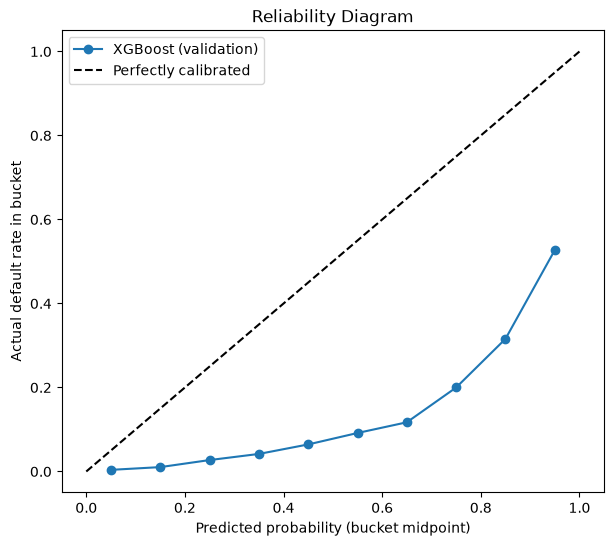

In [5]:
plt.figure(figsize=(7, 6))
plt.plot(summary['predicted_midpoint'], summary['mean'], marker='o', label='XGBoost (validation)')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Predicted probability (bucket midpoint)')
plt.ylabel('Actual default rate in bucket')
plt.title('Reliability Diagram')
plt.legend()
plt.show()


**Finding: severe overconfidence.** The 1,240 people claimed at ~0.75
actually defaulted at 20%. The near-certain bucket (~0.95 claimed) came in
at 52.7%, a coin flip. Every bucket's observed rate sits far below its
claim, a 3-7x inflation across the board: the `scale_pos_weight`
fingerprint. Note the observed-rate column still rises monotonically
bucket over bucket. That is AUC 0.868 made visible: ordering intact,
units broken.

## The fix: isotonic calibration

`CalibratedClassifierCV` does three things. First, with `cv=5` it splits
the data into 5 folds, trains a copy of the model on 4 and scores the held
out fold, rotating so every row gets an honest score from a model that
never trained on it. Second, it fits a correction function through those
(score, outcome) pairs: isotonic regression, a step function constrained
to never decrease, mapping raw score to observed default rate. Third, at
predict time it chains the two: raw score in, corrected probability out.

Because the mapping never decreases, no two people ever swap order, which
is why AUC is untouched. Isotonic (flexible, data-hungry) is chosen over
sigmoid (rigid S-curve) because ~90k training rows is plenty.

In [6]:
xgb_cal = CalibratedClassifierCV(clone(xgb_model), method='isotonic', cv=5)
xgb_cal.fit(X_tr, y_tr)

y_prob_cal = xgb_cal.predict_proba(X_val)[:, 1]

                mean  count  predicted_midpoint
bucket                                         
(0.0, 0.1]  0.026197  24812                0.05
(0.1, 0.2]  0.134664   2354                0.15
(0.2, 0.3]  0.250236   1059                0.25
(0.3, 0.4]  0.335570    745                0.35
(0.4, 0.5]  0.446262    428                0.45
(0.5, 0.6]  0.580524    267                0.55
(0.6, 0.7]  0.633803    213                0.65
(0.7, 0.8]  0.606061     33                0.75
(0.8, 0.9]  0.857143     14                0.85
(0.9, 1.0]  0.625000     16                0.95


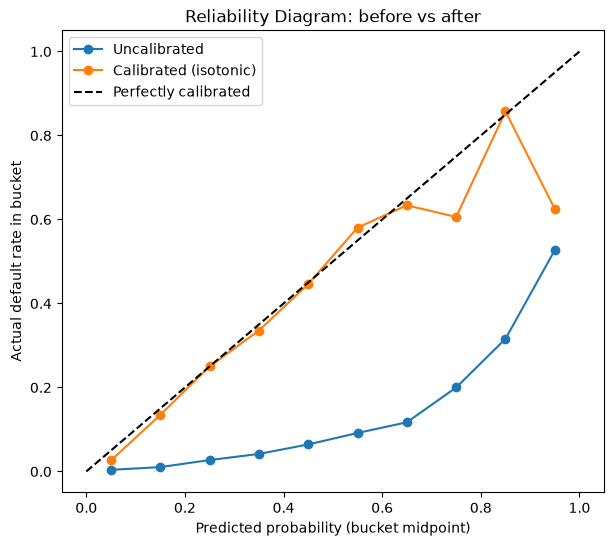

In [7]:
bucket_cal = pd.cut(y_prob_cal, bins=bins)
check_cal = pd.DataFrame({'bucket': bucket_cal, 'actual': y_val.values})
summary_cal = check_cal.groupby('bucket', observed=True)['actual'].agg(['mean', 'count'])
summary_cal['predicted_midpoint'] = [b.mid for b in summary_cal.index]
print(summary_cal)

plt.figure(figsize=(7, 6))
plt.plot(summary['predicted_midpoint'], summary['mean'], marker='o', label='Uncalibrated')
plt.plot(summary_cal['predicted_midpoint'], summary_cal['mean'], marker='o', label='Calibrated (isotonic)')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Predicted probability (bucket midpoint)')
plt.ylabel('Actual default rate in bucket')
plt.title('Reliability Diagram: before vs after')
plt.legend()
plt.show()

**Finding: claims now match reality.** The 0.25 bucket defaults at
25.0%, the 0.45 bucket at 44.6%. The score distribution also compressed
downward honestly: 24,812 of ~30k people now sit below 0.1, consistent
with a 6.7% base rate. The top buckets hold only 14-33 people each, so
their wobbling rates (0.61, 0.86, 0.63) are small-sample noise, not broken
ordering. Isotonic guarantees the mapping is monotonic, but observed rates
in tiny buckets still bounce. Practical consequence: calibrated
predictions above ~0.6 rest on thin validation evidence, worth cautious
phrasing in any downstream explanation.

## Two-number proof: Brier score and AUC

Brier score = average of (claimed probability minus actual outcome)^2
across everyone. Its key property: it is minimized by claiming the true
rate, so overconfidence and hedging both cost points. Lower is better.
Expectation: Brier drops sharply (claims become honest) while AUC stays
put (order never changed).

In [8]:
print("Brier (uncalibrated):", brier_score_loss(y_val, y_prob_val))
print("Brier (calibrated):  ", brier_score_loss(y_val, y_prob_cal))
print("AUC (uncalibrated):  ", roc_auc_score(y_val, y_prob_val))
print("AUC (calibrated):    ", roc_auc_score(y_val, y_prob_cal))

Brier (uncalibrated): 0.14082226157188416
Brier (calibrated):   0.04963271345278434
AUC (uncalibrated):   0.8634407818638794
AUC (calibrated):     0.8639307161636898


**Result: Brier 0.141 -> 0.050 (a 65% drop) while AUC is unchanged
(0.8634 -> 0.8639).** Benchmark for scale: predicting the 0.067 base rate
for everyone scores ~0.062, so the raw model's probability claims were
literally worse than knowing nothing about individual applicants, despite
its strong AUC. Great ranker, terrible forecaster, same model. The
calibrated version is both.

## Re-deriving the threshold in calibrated units

The 0.49 threshold from `04` lives on the inflated raw scale. On the
calibrated scale almost nobody scores that high, so it would flag no one.
KS is invariant to monotonic rescaling, so the same separating power
reappears at a new number on the new scale.

In [9]:
thresholds = np.arange(0.01, 0.96, 0.01)

tpr_list = []
fpr_list = []
for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    tn = ((y_pred_t == 0) & (y_val == 0)).sum()
    tpr_list.append(tp / (tp + fn))
    fpr_list.append(fp / (fp + tn))

ks_values = np.array(tpr_list) - np.array(fpr_list)
best_idx = np.argmax(ks_values)
threshold_cal = thresholds[best_idx]

print(f"Best threshold (calibrated scale): {threshold_cal:.3f}, KS = {ks_values[best_idx]:.3f}")

Best threshold (calibrated scale): 0.060, KS = 0.564


**Result: threshold 0.060 at KS 0.564** (vs. ~0.565 on raw scores in
`04`, confirming rank-invariance: same people flagged, new units). On the
honest scale the rule is readable: flag anyone whose true default
probability exceeds ~6%, i.e. anyone riskier than roughly the average
applicant. The aggressive-recall operating point was always this. The raw
0.49 just disguised it.

## Fit the shipping model on all of X_train

The earlier `xgb_cal` deliberately saw only 75% of the data so the
validation above stayed honest. The artifact that ships should learn from
every training row, the same clone-then-refit discipline used in `04`.

In [10]:
xgb_cal_final = CalibratedClassifierCV(clone(xgb_model), method='isotonic', cv=5)
xgb_cal_final.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001BED845E690>, 

## Save artifacts

The calibrated model and its threshold travel as a pair. A raw-scale
threshold applied to calibrated scores (or vice versa) would silently
misclassify nearly everyone, so `threshold.json` names the model it
belongs to.

In [11]:
joblib.dump(xgb_cal_final, '../models/xgb_calibrated.joblib')

with open('../models/threshold.json', 'w') as f:
    json.dump({
        "model": "xgb_calibrated",
        "threshold": float(threshold_cal),
        "method": "KS / Youden's J maximization on a 25% validation carve-out, calibrated scores",
        "note": "Threshold is in calibrated-probability units and applies to "
                "xgb_calibrated.joblib, not the raw xgb_model.joblib. Supersedes "
                "the earlier 0.49 raw-scale threshold."
    }, f, indent=2)

print("Saved.")

Saved.
